In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# Cell 1 : Install Required Libraries
# ============================================================

print("=" * 80)
print("Installing Required Libraries")
print("=" * 80)

!pip -q install --upgrade pip
# Core libraries
!pip -q install pandas numpy scipy scikit-learn openpyxl

# OpenRouter client
!pip -q install openai

# Embeddings
!pip -q install sentence-transformers

# Vector search
!pip -q install faiss-cpu

# PDF processing
!pip -q install pypdf pdfplumber

# Visualization
!pip -q install matplotlib seaborn plotly

# Utilities
!pip -q install tqdm python-dotenv

print("=" * 80)
print("Installation Complete")
print("=" * 80)

Installing Required Libraries
Installation Complete


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 2 : IMPORTS & ENVIRONMENT SETUP
# ============================================================

import os
import json
import re
import random
import warnings
from getpass import getpass

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

# -----------------------------
# OpenRouter Client
# -----------------------------
from openai import OpenAI

# -----------------------------
# Embedding Model
# -----------------------------
from sentence_transformers import SentenceTransformer

# -----------------------------
# Vector Search
# -----------------------------
import faiss

# -----------------------------
# Statistics
# -----------------------------
from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# -----------------------------
# Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Google Colab Upload
# -----------------------------
from google.colab import files

# ============================================================
# SETTINGS
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("="*80)
print("Environment Initialized Successfully")
print("="*80)

print(f"Numpy Version     : {np.__version__}")
print(f"Pandas Version    : {pd.__version__}")

print("\nLoading Embedding Model...")

embedding_model = SentenceTransformer(
    "BAAI/bge-small-en-v1.5"
)

print("Embedding Model Loaded Successfully")

print("="*80)
print("Ready for OpenRouter Configuration")
print("="*80)

Environment Initialized Successfully
Numpy Version     : 2.0.2
Pandas Version    : 2.2.2

Loading Embedding Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding Model Loaded Successfully
Ready for OpenRouter Configuration


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 3 : OPENROUTER MULTI-API CONFIGURATION
# ============================================================

from getpass import getpass
from openai import OpenAI

print("=" * 80)
print("OPENROUTER MULTI API CONFIGURATION")
print("=" * 80)

# ============================================================
# MODEL
# ============================================================

MODEL_NAME = "deepseek/deepseek-chat"

# ============================================================
# NUMBER OF API KEYS
# ============================================================

NUM_KEYS = 7

# ============================================================
# ENTER API KEYS
# ============================================================

OPENROUTER_KEYS = []

print(f"\nPlease enter {NUM_KEYS} OpenRouter API Keys\n")

for i in range(NUM_KEYS):

    key = getpass(f"API Key {i+1}: ")

    OPENROUTER_KEYS.append(key)

print()

# ============================================================
# CREATE CLIENTS
# ============================================================

clients = []

for key in OPENROUTER_KEYS:

    client = OpenAI(

        api_key=key,

        base_url="https://openrouter.ai/api/v1"

    )

    clients.append(client)

# ============================================================
# DEFAULT CLIENT
# ============================================================

current_client_index = 0

current_client = clients[current_client_index]

print("=" * 80)
print(f"Loaded {len(clients)} API Keys")
print(f"Model : {MODEL_NAME}")
print("=" * 80)

# ============================================================
# TEST ALL KEYS
# ============================================================

print("\nTesting API Keys...\n")

working_keys = 0

for idx, test_client in enumerate(clients):

    print(f"Testing Key {idx+1} ... ", end="")

    try:

        response = test_client.chat.completions.create(

            model=MODEL_NAME,

            messages=[

                {

                    "role":"user",

                    "content":"Reply with ONLY OK."

                }

            ],

            temperature=0,

            max_tokens=5

        )

        print("SUCCESS")

        working_keys += 1

    except Exception as e:

        print("FAILED")

        print(e)

print()

print("=" * 80)
print(f"Working Keys : {working_keys}/{NUM_KEYS}")
print("=" * 80)

if working_keys == 0:

    raise RuntimeError("No valid OpenRouter API Keys found.")

print("\nDefault API Key : 1")

print("=" * 80)
print("OpenRouter Multi-Key Configuration Completed")
print("=" * 80)

OPENROUTER MULTI API CONFIGURATION

Please enter 7 OpenRouter API Keys

API Key 1: ··········
API Key 2: ··········
API Key 3: ··········
API Key 4: ··········
API Key 5: ··········
API Key 6: ··········
API Key 7: ··········

Loaded 7 API Keys
Model : deepseek/deepseek-chat

Testing API Keys...

Testing Key 1 ... SUCCESS
Testing Key 2 ... SUCCESS
Testing Key 3 ... SUCCESS
Testing Key 4 ... SUCCESS
Testing Key 5 ... SUCCESS
Testing Key 6 ... SUCCESS
Testing Key 7 ... SUCCESS

Working Keys : 7/7

Default API Key : 1
OpenRouter Multi-Key Configuration Completed


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 4 : LOAD & VALIDATE DATASET
# ============================================================

print("=" * 80)
print("Loading CareerCorpus Dataset")
print("=" * 80)

# ------------------------------------------------------------
# Upload Dataset
# ------------------------------------------------------------

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("No dataset uploaded.")

dataset_path = list(uploaded.keys())[0]

print(f"\nDataset Uploaded : {dataset_path}")

# ------------------------------------------------------------
# Read Excel File
# ------------------------------------------------------------

try:
    df = pd.read_excel(dataset_path)
except Exception as e:
    raise RuntimeError(f"Unable to read dataset: {e}")

print("\nDataset Loaded Successfully")

# ------------------------------------------------------------
# Standardize Column Names
# ------------------------------------------------------------

df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

# ------------------------------------------------------------
# Display Dataset Information
# ------------------------------------------------------------

print("\nDataset Shape")
print(df.shape)

print("\nColumns")

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nMissing Values")

display(df.isnull().sum())

print("\nFirst Five Records")

display(df.head())

# ------------------------------------------------------------
# Validate Required Columns
# ------------------------------------------------------------

required_columns = [

    "ID",

    "Domain",

    "Education",

    "Skills and Achievements",

    "Experience",

    "Job_type",

    "Annotator-1",

    "Annotator-2"

]

missing_columns = [

    c for c in required_columns

    if c not in df.columns

]

if missing_columns:

    raise ValueError(

        f"Missing Columns: {missing_columns}"

    )

print("\nAll Required Columns Found")

# ------------------------------------------------------------
# Remove Duplicate Records
# ------------------------------------------------------------

before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"\nDuplicate Rows Removed : {before-after}")

# ------------------------------------------------------------
# Reset Index
# ------------------------------------------------------------

df = df.reset_index(drop=True)

# ------------------------------------------------------------
# Dataset Summary
# ------------------------------------------------------------

print("\nSummary")

print(f"Total Resumes : {len(df)}")

print(f"Domains        : {df['Domain'].nunique()}")

print(f"Job Types      : {df['Job_type'].nunique()}")

print("="*80)
print("Dataset Validation Completed")
print("="*80)

Loading CareerCorpus Dataset


Saving CareerCorpus.xlsx to CareerCorpus.xlsx

Dataset Uploaded : CareerCorpus.xlsx

Dataset Loaded Successfully

Dataset Shape
(302, 8)

Columns
1. ID
2. Domain
3. Education
4. Skills and Achievements
5. Experience
6. Job_type
7. Annotator-1
8. Annotator-2

Missing Values


,0
ID,0
Domain,0
Education,0
Skills and Achievements,0
Experience,0
Job_type,0
Annotator-1,0
Annotator-2,0



First Five Records


,ID,Domain,Education,Skills and Achievements,Experience,Job_type,Annotator-1,Annotator-2
0,74552449,Banking,"Master of Science in International Trade, Universidad Carlos III de Madrid, Spain (2014) — coursework in international trade policies and laws. Bachelor of Science in Business Administration and D...","Skilled in cash handling, loan operations, financial reporting, analysis, and risk identification. Proficient in MS Excel and MS Office; adept at business negotiation, communication, and team lead...","Professional (11/2016–Present)—opened and managed customer accounts (checking, savings, credit lines), balanced vault inventory with zero error rate, ensured regulatory compliance, and provided cl...",Entry-level,0.80,0.88
1,79041971,Banking,"High School Diploma, Federal Way Senior High School, United States (2010","Strong leadership, team management, and client relations abilities. Skilled in supervision, staff training, multitasking, and decision-making under pressure. Proficient in recruiting, sales growth...","Banking Professional (Aug 2013–Present)—oversees daily operations, client service, and staff performance within the banking domain. Store Manager (Aug 2012–Nov 2012)—managed team of 10; launched n...",Mid-level,0.40,0.75
2,77156708,Banking,"Master of Management, Business Management — Colorado State University (05/2017). Bachelor of Arts, Applied Economics — National University of Kaohsiung, Taiwan (05/2013).",NMLS #1796859; business development; project management; Confluence/Jira/Salesforce/SQL; financial analysis & statements; pricing strategy; budgeting; credit/underwriting; due diligence; documenta...,Banking Officer (10/2018–Current)—BSA/AML/OFAC compliance; credit analysis & underwriting; top producer; realtor & SMB relationships; supervised Asian Banking Center and community outreach. Direct...,Mid-level,0.84,0.97
3,24580361,Banking,"B.S. in Operations Management, University of Delaware (2013); Minor in Economics; GPA 3.978/4.0. Awards: Distinguished Operations Management Junior, Alpha Lambda Delta, National Society of Collegi...","Microsoft Office (Excel/PowerPoint/Word/Access), SAP, Minitab, Maple, Lingo, HTML; Six Sigma exposure; detail-oriented, analytical, troubleshooting/problem solving; strong communication, time mana...","Associate, Investment Banking Operations (07/2013–Present)—operations role (firm/city undisclosed). Intern, Syndicated Loan Operations (06/2012–12/2012)—maintained 150+ deals/1000+ loans; processe...",Senior-level,0.76,0.97
4,34953092,Banking,"M.S. Computer Engineering, University of Missouri–Columbia (2016), GPA 3.46; Graduate Research Assistant. B.S. Finance & Banking, University of Missouri–Columbia (2013), Minor in Mathematics; VP, ...","C/C++, Python, MATLAB, SQL, R, LUA, VBA; ML (supervised/unsupervised/DNN); forecasting & financial analysis; English/Chinese. Built VBA systems improving workflow (up to 20%); SQL research; image-...","Corporate Banking Assistant, Intern (May–Aug 2015)—commercial mortgage risk reports (appraisal, cash flow, RAROC, sensitivity), SME research in SQL, VBA documentation system. Office Assistant, Int...",Entry-level,0.76,0.88



All Required Columns Found

Duplicate Rows Removed : 0

Summary
Total Resumes : 302
Domains        : 6
Job Types      : 4
Dataset Validation Completed


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 5 : ADVANCED RESUME PREPROCESSING
# ============================================================

print("=" * 80)
print("Advanced Resume Preprocessing")
print("=" * 80)

# ------------------------------------------------------------
# Fill Missing Values
# ------------------------------------------------------------

text_columns = [
    "Education",
    "Skills and Achievements",
    "Experience",
    "Domain",
    "Job_type"
]

for col in text_columns:
    df[col] = df[col].fillna("Not Available").astype(str)

# ------------------------------------------------------------
# Calculate Ground Truth Score
# ------------------------------------------------------------

df["ground_truth_score"] = (
    df["Annotator-1"] +
    df["Annotator-2"]
) / 2

# ------------------------------------------------------------
# Standardize Job Level
# ------------------------------------------------------------

def infer_job_level(job):

    job = str(job).lower()

    if any(k in job for k in [
        "intern",
        "junior",
        "entry",
        "trainee"
    ]):
        return "Junior"

    elif any(k in job for k in [
        "senior",
        "lead",
        "manager"
    ]):
        return "Senior"

    elif any(k in job for k in [
        "director",
        "head",
        "chief",
        "vp"
    ]):
        return "Leadership"

    return "Mid-Level"

df["job_level"] = df["Job_type"].apply(infer_job_level)

# ------------------------------------------------------------
# Resume Constructor
# ------------------------------------------------------------

def build_resume(row):

    return f"""
Domain:
{row['Domain']}

Target Job:
{row['Job_type']}

Education:
{row['Education']}

Skills and Achievements:
{row['Skills and Achievements']}

Experience:
{row['Experience']}
""".strip()

df["resume_text"] = df.apply(
    build_resume,
    axis=1
)

# ------------------------------------------------------------
# Clean Resume Text
# ------------------------------------------------------------

def clean_resume(text):

    text = re.sub(r"\n+", "\n", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["resume_text"] = df["resume_text"].apply(clean_resume)

# ------------------------------------------------------------
# Resume Statistics
# ------------------------------------------------------------

df["word_count"] = df["resume_text"].apply(
    lambda x: len(x.split())
)

df["character_count"] = df["resume_text"].apply(
    len
)

# ------------------------------------------------------------
# Structured Resume Object
# ------------------------------------------------------------

def create_resume_object(row):

    return {

        "resume_id": row["ID"],

        "domain": row["Domain"],

        "job_type": row["Job_type"],

        "job_level": row["job_level"],

        "education": row["Education"],

        "skills": row["Skills and Achievements"],

        "experience": row["Experience"],

        "ground_truth_score": float(row["ground_truth_score"]),

        "resume_text": row["resume_text"]

    }

df["resume_object"] = df.apply(
    create_resume_object,
    axis=1
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\nPreprocessing Completed Successfully\n")

print(f"Total Resumes : {len(df)}")

print(f"Average Resume Length : {df['word_count'].mean():.2f} words")

print("\nJob Level Distribution")

display(df["job_level"].value_counts())

print("\nSample Resume\n")

print(df.loc[0, "resume_text"][:1000])

print("\nStructured Resume Object\n")

print(json.dumps(df.loc[0, "resume_object"], indent=4))

print("=" * 80)
print("Resume Preprocessing Completed")
print("=" * 80)

Advanced Resume Preprocessing

Preprocessing Completed Successfully

Total Resumes : 302
Average Resume Length : 111.59 words

Job Level Distribution


,count
job_level,
Senior,174
Junior,71
Mid-Level,57



Sample Resume

Domain: Banking Target Job: Entry-level Education: Master of Science in International Trade, Universidad Carlos III de Madrid, Spain (2014) — coursework in international trade policies and laws. Bachelor of Science in Business Administration and Direction, Universidad Pública de Navarra, Spain (2013) Skills and Achievements: Skilled in cash handling, loan operations, financial reporting, analysis, and risk identification. Proficient in MS Excel and MS Office; adept at business negotiation, communication, and team leadership. Multilingual (Spanish). Experienced with Salesforce, TapScan, Photoshop, Illustrator, HTML, and public relations tools such as Factiva and Bacon’s Mediasource. Recognized for client interfacing and developing marketing strategies to drive business growth Experience: Professional (11/2016–Present)—opened and managed customer accounts (checking, savings, credit lines), balanced vault inventory with zero error rate, ensured regulatory compliance, and p

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 6 : BUILD EXTERNAL KNOWLEDGE BASE
# ============================================================

print("=" * 80)
print("Building External Knowledge Base")
print("=" * 80)

knowledge_base = []

# ------------------------------------------------------------
# Helper Function
# ------------------------------------------------------------

def add_document(doc_type, domain, title, content):

    knowledge_base.append({

        "document_type": doc_type,

        "domain": domain,

        "title": title,

        "content": content

    })

# ============================================================
# DOMAIN KNOWLEDGE
# ============================================================

domains = sorted(df["Domain"].dropna().unique())

print(f"Detected Domains ({len(domains)}):")

for d in domains:
    print("•", d)

print()

for domain in domains:

    add_document(

        "Job Description",

        domain,

        f"{domain} Job Description",

f"""
This position belongs to the {domain} domain.

Evaluation should focus on:

• Domain Knowledge
• Technical Skills
• Relevant Experience
• Educational Background
• Communication
• Problem Solving
• Achievements
• Professional Growth
• Role Alignment

Candidates should demonstrate practical
knowledge related to the {domain} industry.
"""

    )

# ============================================================
# COMPANY HIRING POLICY
# ============================================================

company_policy = """
General Company Hiring Policy

Evaluation Criteria

1. Relevant Skills

2. Relevant Experience

3. Education

4. Domain Knowledge

5. Communication

6. Leadership

7. Professional Certifications

8. Career Progression

9. Problem Solving

10. Overall Resume Quality

Evidence from the resume should always
be preferred over assumptions.
"""

add_document(

    "Company Policy",

    "General",

    "Company Hiring Policy",

    company_policy

)

# ============================================================
# PROFESSIONAL CERTIFICATIONS
# ============================================================

certifications = """
Professional Certifications

Technology

AWS

Azure

Google Cloud

Cisco

Oracle Java

RedHat

Finance

CPA

CFA

FRM

Teaching

Teaching License

TESOL

CELTA

Healthcare

BLS

ACLS

PALS

Professional certifications strengthen
the overall evaluation whenever relevant.
"""

add_document(

    "Certification Guide",

    "General",

    "Professional Certifications",

    certifications

)

# ============================================================
# UNIVERSITY RANKING GUIDE
# ============================================================

university_rankings = """
University Ranking Guidelines

Tier 1

MIT
Stanford
Oxford
Cambridge
Harvard
ETH Zurich

Tier 2

NUS
Imperial College
IIT Bombay
IIT Delhi
IIT Madras
University of Toronto

Tier 3

Accredited National Universities

Tier 4

Regional Universities

Education should contribute to the
overall evaluation but should not
dominate the final hiring score.
"""

add_document(

    "University Ranking",

    "General",

    "University Ranking Guide",

    university_rankings

)

# ============================================================
# INDUSTRY HIRING GUIDELINES
# ============================================================

industry_guidelines = """
General Resume Evaluation Guidelines

Evaluate:

• Technical Skills

• Experience

• Communication

• Leadership

• Achievements

• Education

• Certifications

• Domain Knowledge

• Career Growth

• Job Fit

Final scores should always be supported
by evidence extracted from the resume.
"""

add_document(

    "Hiring Guideline",

    "General",

    "Industry Hiring Guidelines",

    industry_guidelines

)

# ============================================================
# Convert to DataFrame
# ============================================================

knowledge_df = pd.DataFrame(knowledge_base)

print()

print("Knowledge Documents Created")

print(len(knowledge_df))

print()

display(knowledge_df.head())

print()

print("=" * 80)
print("Knowledge Base Ready")
print("=" * 80)

Building External Knowledge Base
Detected Domains (6):
• ACCOUNTANT
• Apparel
• Banking
• Finance
• Research Assistant
• TEACHER


Knowledge Documents Created
10



,document_type,domain,title,content
0,Job Description,ACCOUNTANT,ACCOUNTANT Job Description,\nThis position belongs to the ACCOUNTANT domain.\n\nEvaluation should focus on:\n\n• Domain Knowledge\n• Technical Skills\n• Relevant Experience\n• Educational Background\n• Communication\n• Prob...
1,Job Description,Apparel,Apparel Job Description,\nThis position belongs to the Apparel domain.\n\nEvaluation should focus on:\n\n• Domain Knowledge\n• Technical Skills\n• Relevant Experience\n• Educational Background\n• Communication\n• Problem...
2,Job Description,Banking,Banking Job Description,\nThis position belongs to the Banking domain.\n\nEvaluation should focus on:\n\n• Domain Knowledge\n• Technical Skills\n• Relevant Experience\n• Educational Background\n• Communication\n• Problem...
3,Job Description,Finance,Finance Job Description,\nThis position belongs to the Finance domain.\n\nEvaluation should focus on:\n\n• Domain Knowledge\n• Technical Skills\n• Relevant Experience\n• Educational Background\n• Communication\n• Problem...
4,Job Description,Research Assistant,Research Assistant Job Description,\nThis position belongs to the Research Assistant domain.\n\nEvaluation should focus on:\n\n• Domain Knowledge\n• Technical Skills\n• Relevant Experience\n• Educational Background\n• Communication...



Knowledge Base Ready


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 7 : BUILD FAISS VECTOR DATABASE
# ============================================================

print("=" * 80)
print("Building FAISS Vector Database")
print("=" * 80)

documents = []
metadata = []

# ============================================================
# Add Resume Documents
# ============================================================

for _, row in df.iterrows():

    documents.append(row["resume_text"])

    metadata.append({

        "source": "resume",

        "resume_id": row["ID"],

        "domain": row["Domain"],

        "job_type": row["Job_type"],

        "job_level": row["job_level"],

        "ground_truth_score": row["ground_truth_score"]

    })

# ============================================================
# Add Knowledge Documents
# ============================================================

for _, row in knowledge_df.iterrows():

    documents.append(row["content"])

    metadata.append({

        "source": row["document_type"],

        "domain": row["domain"],

        "title": row["title"]

    })

print(f"Total Documents : {len(documents)}")

# ============================================================
# Generate Embeddings
# ============================================================

print("\nGenerating Embeddings...\n")

embeddings = embedding_model.encode(

    documents,

    batch_size=32,

    show_progress_bar=True,

    normalize_embeddings=True

)

embeddings = np.asarray(embeddings).astype("float32")

print("\nEmbedding Shape")

print(embeddings.shape)

# ============================================================
# Create FAISS Index
# ============================================================

dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("\nFAISS Index Created")

print(f"Indexed Documents : {index.ntotal}")

# ============================================================
# Retrieval Function
# ============================================================

def retrieve_context(

    query,

    top_k=5

):

    query_embedding = embedding_model.encode(

        [query],

        normalize_embeddings=True

    ).astype("float32")

    scores, indices = index.search(

        query_embedding,

        top_k

    )

    results = []

    for score, idx in zip(scores[0], indices[0]):

        results.append({

            "score": float(score),

            "metadata": metadata[idx],

            "content": documents[idx]

        })

    return results

# ============================================================
# Test Retrieval
# ============================================================

print("\nTesting Retrieval\n")

sample_query = (
    "Finance candidate with strong accounting "
    "skills and CPA certification"
)

results = retrieve_context(sample_query)

for i, result in enumerate(results, 1):

    print("-" * 80)

    print(f"Result {i}")

    print()

    print("Similarity Score")

    print(round(result["score"], 4))

    print()

    print("Metadata")

    print(result["metadata"])

    print()

    print("Content Preview")

    print(result["content"][:350])

print("-" * 80)

print("\nRAG Vector Database Ready")

print("=" * 80)

Building FAISS Vector Database
Total Documents : 312

Generating Embeddings...



Batches:   0%|          | 0/10 [00:00<?, ?it/s]


Embedding Shape
(312, 384)

FAISS Index Created
Indexed Documents : 312

Testing Retrieval

--------------------------------------------------------------------------------
Result 1

Similarity Score
0.7644

Metadata
{'source': 'resume', 'resume_id': 84356308, 'domain': 'Finance', 'job_type': 'Senior-level', 'job_level': 'Senior', 'ground_truth_score': 0.905}

Content Preview
Domain: Finance Target Job: Senior-level Education: B.S. Mathematics, University of the Punjab (1997). CPA (Institute of Certified Public Accountants, 2012). Skills and Achievements: Corporate finance, M&A/IPO, due diligence & valuation, IFRS/US GAAP, financial modeling, budgeting/forecasting, treasury, taxation, ERP, internal controls/SOX, risk ma
--------------------------------------------------------------------------------
Result 2

Similarity Score
0.7615

Metadata
{'source': 'resume', 'resume_id': 26530575, 'domain': 'Finance', 'job_type': 'Senior-level', 'job_level': 'Senior', 'ground_truth_score': 0.91}


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 8 : SHARED UTILITY FUNCTIONS
# (MULTI API VERSION)
# ============================================================

print("=" * 80)
print("Initializing Shared Utility Functions")
print("=" * 80)

import json
import re
import time

# ============================================================
# CURRENT API CLIENT
# ============================================================

current_client_index = 0
current_client = clients[current_client_index]

# ============================================================
# SWITCH API KEY
# ============================================================

def set_api_key(index):
    """
    Switch OpenRouter API Key
    """

    global current_client
    global current_client_index

    if index >= len(clients):
        raise RuntimeError("No more API Keys available.")

    current_client_index = index
    current_client = clients[index]

    print()
    print("=" * 80)
    print(f"Using API Key {index+1}/{len(clients)}")
    print("=" * 80)


# ============================================================
# MOVE TO NEXT KEY
# ============================================================

def switch_to_next_key():

    global current_client_index

    if current_client_index + 1 >= len(clients):

        raise RuntimeError(
            "All OpenRouter API Keys exhausted."
        )

    set_api_key(current_client_index + 1)


# ============================================================
# OPENROUTER CHAT FUNCTION
# ============================================================

def chat_with_llm(
    system_prompt,
    user_prompt,
    model=MODEL_NAME,
    temperature=0.2,
    max_tokens=2500,
    retries=3
):
    """
    Generic OpenRouter Chat Function

    Automatically switches API Keys
    if one key fails.
    """

    global current_client

    attempt = 0

    while attempt < retries:

        try:

            response = current_client.chat.completions.create(

                model=model,

                temperature=temperature,

                max_tokens=max_tokens,

                messages=[

                    {

                        "role":"system",

                        "content":system_prompt

                    },

                    {

                        "role":"user",

                        "content":user_prompt

                    }

                ]

            )

            return response.choices[0].message.content.strip()

        except Exception as e:

            error = str(e)

            print()
            print("-"*60)
            print(error)
            print("-"*60)

            # --------------------------------------
            # Credits exhausted / Rate limit
            # --------------------------------------

            if (

                "402" in error

                or

                "429" in error

                or

                "credits" in error.lower()

                or

                "rate" in error.lower()

            ):

                print()

                print("Switching to next API Key...")

                switch_to_next_key()

                continue

            attempt += 1

            print(

                f"Retry {attempt}/{retries}"

            )

            time.sleep(2)

    raise RuntimeError(

        "LLM request failed."

    )

# ============================================================
# EXTRACT JSON
# ============================================================

def extract_json(text):

    text = text.strip()

    match = re.search(

        r"\{.*\}",

        text,

        re.DOTALL

    )

    if match:

        try:

            return json.loads(

                match.group()

            )

        except:

            pass

    return json.loads(text)

# ============================================================
# NORMALIZE SCORE
# ============================================================

def normalize_score(

    score,

    minimum=0,

    maximum=10

):

    score=float(score)

    score=max(minimum,score)

    score=min(maximum,score)

    return round(score,2)

# ============================================================
# PRETTY JSON
# ============================================================

def pretty_json(data):

    print(

        json.dumps(

            data,

            indent=4,

            ensure_ascii=False

        )

    )

# ============================================================
# RAG CONTEXT
# ============================================================

def get_rag_context(

    query,

    top_k=5

):

    results=retrieve_context(

        query,

        top_k

    )

    context=""

    for i,item in enumerate(results,1):

        context+=f"""

DOCUMENT {i}

SOURCE
{item['metadata']}

CONTENT

{item['content']}

"""

    return context

# ============================================================
# PREVIEW RESUME
# ============================================================

def preview_resume(index=0):

    print("="*80)

    print(df.loc[index,"resume_text"])

    print("="*80)

# ============================================================
# TEST
# ============================================================

print()

print("Testing Utility Functions...")

sample=retrieve_context(

    "Software Engineer Python"

)

print()

print(

    "Retrieved",

    len(sample),

    "documents"

)

print()

print(

    "Current API Key :",

    current_client_index+1

)

print()

print("="*80)

print("Utility Functions Ready")

print("="*80)

Initializing Shared Utility Functions

Testing Utility Functions...

Retrieved 5 documents

Current API Key : 1

Utility Functions Ready


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 9 : RESUME EXTRACTOR AGENT
# ============================================================

print("=" * 80)
print("Initializing Resume Extractor Agent")
print("=" * 80)

# ============================================================
# SYSTEM PROMPT
# ============================================================

RESUME_EXTRACTOR_SYSTEM_PROMPT = """
You are the Resume Extractor Agent in an AI Hiring System.

Your ONLY responsibility is to convert an unstructured resume
into structured JSON.

DO NOT evaluate the candidate.

DO NOT assign scores.

DO NOT recommend hiring.

Return ONLY valid JSON.

Required JSON format:

{
    "candidate_name":"",
    "target_job":"",
    "domain":"",
    "education":[],
    "skills":[],
    "experience":[],
    "certifications":[],
    "projects":[],
    "achievements":[],
    "summary":""
}
"""

# ============================================================
# Resume Extractor Function
# ============================================================

def resume_extractor_agent(resume_text):

    user_prompt = f"""
Extract all important information from the following resume.

Resume:

{resume_text}
"""

    response = chat_with_llm(

        system_prompt=RESUME_EXTRACTOR_SYSTEM_PROMPT,

        user_prompt=user_prompt,

        temperature=0

    )

    try:

        structured_resume = extract_json(response)

    except Exception:

        structured_resume = {

            "candidate_name": "",

            "target_job": "",

            "domain": "",

            "education": [],

            "skills": [],

            "experience": [],

            "certifications": [],

            "projects": [],

            "achievements": [],

            "summary": response

        }

    return structured_resume

# ============================================================
# Test Resume Extractor
# ============================================================

print("\nTesting Resume Extractor Agent...\n")

sample_resume = df.loc[0, "resume_text"]

structured_resume = resume_extractor_agent(sample_resume)

print("Structured Resume\n")

pretty_json(structured_resume)

print()

print("=" * 80)
print("Resume Extractor Agent Ready")
print("=" * 80)

Initializing Resume Extractor Agent

Testing Resume Extractor Agent...

Structured Resume

{
    "candidate_name": "",
    "target_job": "Entry-level",
    "domain": "Banking",
    "education": [
        "Master of Science in International Trade, Universidad Carlos III de Madrid, Spain (2014)",
        "Bachelor of Science in Business Administration and Direction, Universidad Pública de Navarra, Spain (2013)"
    ],
    "skills": [
        "Cash handling",
        "Loan operations",
        "Financial reporting",
        "Analysis",
        "Risk identification",
        "MS Excel",
        "MS Office",
        "Business negotiation",
        "Communication",
        "Team leadership",
        "Multilingual (Spanish)",
        "Salesforce",
        "TapScan",
        "Photoshop",
        "Illustrator",
        "HTML",
        "Public relations tools (Factiva, Bacon’s Mediasource)"
    ],
    "experience": [
        {
            "role": "Professional",
            "duration": "11/2016–

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 10 : RESUME EVALUATOR AGENT
# ============================================================

print("=" * 80)
print("Initializing Resume Evaluator Agent")
print("=" * 80)

# ============================================================
# SYSTEM PROMPT
# ============================================================

RESUME_EVALUATOR_SYSTEM_PROMPT = """
You are the Resume Evaluator Agent.

Your responsibility is to evaluate the candidate
using BOTH:

1. Structured Resume
2. Retrieved External Knowledge

Evaluate ONLY using evidence.

Return ONLY valid JSON.

JSON Format:

{
    "education_score":0,
    "skills_score":0,
    "experience_score":0,
    "certification_score":0,
    "domain_score":0,

    "overall_score":0,

    "strengths":[
    ],

    "weaknesses":[
    ],

    "recommendations":[
    ],

    "reasoning":""
}

Scoring Rules

Each category

0-10

Overall

0-10

Never invent information.

Always justify scores using the retrieved context.
"""

# ============================================================
# Resume Evaluator
# ============================================================

def resume_evaluator_agent(

    structured_resume

):

    # ----------------------------
    # Build Retrieval Query
    # ----------------------------

    query = f"""

Domain:

{structured_resume.get("domain","")}

Target Job:

{structured_resume.get("target_job","")}

Skills:

{structured_resume.get("skills",[])}

Experience:

{structured_resume.get("experience",[])}

"""

    # ----------------------------
    # Retrieve External Knowledge
    # ----------------------------

    rag_context = get_rag_context(

        query,

        top_k=5

    )

    # ----------------------------
    # User Prompt
    # ----------------------------

    user_prompt = f"""

Structured Resume

{json.dumps(structured_resume,indent=2)}

Retrieved Knowledge

{rag_context}

Evaluate this candidate.

"""

    response = chat_with_llm(

        system_prompt=RESUME_EVALUATOR_SYSTEM_PROMPT,

        user_prompt=user_prompt,

        temperature=0

    )

    try:

        result = extract_json(

            response

        )

    except Exception:

        result = {

            "education_score":0,

            "skills_score":0,

            "experience_score":0,

            "certification_score":0,

            "domain_score":0,

            "overall_score":0,

            "strengths":[],

            "weaknesses":[],

            "recommendations":[],

            "reasoning":response

        }

    # ----------------------------
    # Normalize Scores
    # ----------------------------

    score_columns = [

        "education_score",

        "skills_score",

        "experience_score",

        "certification_score",

        "domain_score",

        "overall_score"

    ]

    for c in score_columns:

        result[c] = normalize_score(

            result.get(c,0)

        )

    return result

# ============================================================
# Test Evaluator
# ============================================================

print()

print("Testing Resume Evaluator...\n")

structured_resume = resume_extractor_agent(

    df.loc[0,"resume_text"]

)

evaluation = resume_evaluator_agent(

    structured_resume

)

pretty_json(

    evaluation

)

print()

print("="*80)

print("Resume Evaluator Ready")

print("="*80)

Initializing Resume Evaluator Agent

Testing Resume Evaluator...

{
    "education_score": 8.0,
    "skills_score": 7.0,
    "experience_score": 7.0,
    "certification_score": 0,
    "domain_score": 8.0,
    "overall_score": 7.0,
    "strengths": [
        "Strong educational background with a Master's degree in International Trade and a Bachelor's degree in Business Administration.",
        "Relevant experience in banking roles, including account management, customer service, and regulatory compliance.",
        "Proficiency in key banking skills such as cash handling, loan operations, and financial reporting.",
        "Multilingual capabilities, particularly in Spanish, which is valuable in diverse banking environments.",
        "Recognition for client interfacing and developing marketing strategies to drive business growth."
    ],
    "weaknesses": [
        "Lack of certifications relevant to the banking domain, which could enhance credibility and expertise.",
        "Limited

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 11 : CEO AGENT
# ============================================================

print("=" * 80)
print("Initializing CEO Agent")
print("=" * 80)

# ============================================================
# CEO SYSTEM PROMPT
# ============================================================

CEO_SYSTEM_PROMPT = """
You are the CEO Agent.

Your responsibility is to review the Resume Evaluator's report
from a strategic business perspective.

Do NOT re-evaluate technical skills.

Focus on:

• Overall candidate potential
• Leadership capability
• Career growth
• Long-term value
• Strategic hiring value

Return ONLY valid JSON.

{
    "leadership_score":0,
    "business_alignment_score":0,
    "growth_potential_score":0,
    "overall_ceo_score":0,
    "decision":"Proceed / Hold / Reject",
    "reasoning":""
}
"""

# ============================================================
# CEO Agent
# ============================================================

def ceo_agent(

    structured_resume,

    evaluator_report

):

    user_prompt = f"""

Candidate Information

{json.dumps(structured_resume, indent=2)}

Resume Evaluator Report

{json.dumps(evaluator_report, indent=2)}

Provide the CEO assessment.

"""

    response = chat_with_llm(

        system_prompt=CEO_SYSTEM_PROMPT,

        user_prompt=user_prompt,

        temperature=0

    )

    try:

        result = extract_json(response)

    except:

        result = {

            "leadership_score":0,

            "business_alignment_score":0,

            "growth_potential_score":0,

            "overall_ceo_score":0,

            "decision":"Hold",

            "reasoning":response

        }

    # Normalize scores
    for key in [

        "leadership_score",

        "business_alignment_score",

        "growth_potential_score",

        "overall_ceo_score"

    ]:

        result[key] = normalize_score(

            result.get(key,0)

        )

    return result

# ============================================================
# Test CEO Agent
# ============================================================

print()

print("Testing CEO Agent...\n")

structured_resume = resume_extractor_agent(

    df.loc[0,"resume_text"]

)

evaluation = resume_evaluator_agent(

    structured_resume

)

ceo_result = ceo_agent(

    structured_resume,

    evaluation

)

pretty_json(

    ceo_result

)

print()

print("="*80)

print("CEO Agent Ready")

print("="*80)

Initializing CEO Agent

Testing CEO Agent...

{
    "leadership_score": 6.0,
    "business_alignment_score": 7.0,
    "growth_potential_score": 7.0,
    "overall_ceo_score": 6.7,
    "decision": "Proceed",
    "reasoning": "The candidate demonstrates solid foundational skills and experience in banking operations, aligning well with an entry-level role. Their multilingual ability and recognition for client interfacing add strategic value. While leadership capabilities are not extensively demonstrated, their growth potential and alignment with business needs make them a viable candidate. Recommendations include obtaining relevant certifications to further enhance their candidacy."
}

CEO Agent Ready


In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 12 : CTO AGENT
# ============================================================

print("=" * 80)
print("Initializing CTO Agent")
print("=" * 80)

# ============================================================
# CTO SYSTEM PROMPT
# ============================================================

CTO_SYSTEM_PROMPT = """
You are the CTO Agent.

Your ONLY responsibility is to evaluate the candidate's
technical capability.

Do NOT evaluate leadership.

Do NOT evaluate HR aspects.

Focus on:

1. Technical Skills
2. Programming Skills
3. Projects
4. Technical Experience
5. Problem Solving
6. Technology Stack
7. Engineering Readiness

Return ONLY valid JSON.

{
    "technical_skill_score":0,
    "project_score":0,
    "problem_solving_score":0,
    "engineering_readiness_score":0,
    "overall_cto_score":0,
    "technical_strengths":[],
    "technical_gaps":[],
    "decision":"Proceed / Hold / Reject",
    "reasoning":""
}
"""

# ============================================================
# CTO Agent
# ============================================================

def cto_agent(
    structured_resume,
    evaluator_report
):

    user_prompt = f"""
Structured Resume

{json.dumps(structured_resume, indent=2)}

Resume Evaluator Report

{json.dumps(evaluator_report, indent=2)}

Provide the CTO assessment.
"""

    response = chat_with_llm(
        system_prompt=CTO_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        temperature=0
    )

    try:
        result = extract_json(response)

    except Exception:

        result = {
            "technical_skill_score":0,
            "project_score":0,
            "problem_solving_score":0,
            "engineering_readiness_score":0,
            "overall_cto_score":0,
            "technical_strengths":[],
            "technical_gaps":[],
            "decision":"Hold",
            "reasoning":response
        }

    score_columns = [
        "technical_skill_score",
        "project_score",
        "problem_solving_score",
        "engineering_readiness_score",
        "overall_cto_score"
    ]

    for col in score_columns:
        result[col] = normalize_score(
            result.get(col,0)
        )

    return result

# ============================================================
# Test CTO Agent
# ============================================================

print("\nTesting CTO Agent...\n")

structured_resume = resume_extractor_agent(
    df.loc[0,"resume_text"]
)

evaluation = resume_evaluator_agent(
    structured_resume
)

cto_result = cto_agent(
    structured_resume,
    evaluation
)

pretty_json(cto_result)

print("\n")

print("="*80)
print("CTO Agent Ready")
print("="*80)

Initializing CTO Agent

Testing CTO Agent...

{
    "technical_skill_score": 2.0,
    "project_score": 0,
    "problem_solving_score": 1.0,
    "engineering_readiness_score": 1.0,
    "overall_cto_score": 1.0,
    "technical_strengths": [
        "Basic knowledge of HTML",
        "Proficiency in MS Excel and MS Office"
    ],
    "technical_gaps": [
        "Lack of advanced programming skills",
        "No experience with modern software development tools or frameworks",
        "No demonstrated experience in software engineering or technical problem-solving",
        "No projects or technical achievements listed"
    ],
    "decision": "Reject",
    "reasoning": "The candidate lacks the necessary technical skills, programming experience, and engineering readiness for a technical role. While they have basic knowledge of HTML and proficiency in MS Excel, there is no evidence of advanced technical capabilities, problem-solving skills, or relevant projects. The resume is more aligned wi

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 13 : HR AGENT
# ============================================================

print("=" * 80)
print("Initializing HR Agent")
print("=" * 80)

# ============================================================
# HR SYSTEM PROMPT
# ============================================================

HR_SYSTEM_PROMPT = """
You are the HR Agent.

Your ONLY responsibility is to evaluate the candidate
from an HR perspective.

Do NOT evaluate technical expertise.

Do NOT evaluate business strategy.

Evaluate only:

1. Communication
2. Teamwork
3. Adaptability
4. Professionalism
5. Career Stability
6. Cultural Fit

Return ONLY valid JSON.

{
    "communication_score":0,
    "teamwork_score":0,
    "adaptability_score":0,
    "professionalism_score":0,
    "culture_fit_score":0,
    "overall_hr_score":0,
    "strengths":[],
    "concerns":[],
    "decision":"Proceed / Hold / Reject",
    "reasoning":""
}
"""

# ============================================================
# HR AGENT
# ============================================================

def hr_agent(
    structured_resume,
    evaluator_report
):

    user_prompt = f"""
Structured Resume

{json.dumps(structured_resume, indent=2)}

Resume Evaluator Report

{json.dumps(evaluator_report, indent=2)}

Provide the HR assessment.
"""

    response = chat_with_llm(

        system_prompt=HR_SYSTEM_PROMPT,

        user_prompt=user_prompt,

        temperature=0

    )

    try:

        result = extract_json(response)

    except Exception:

        result = {

            "communication_score":0,
            "teamwork_score":0,
            "adaptability_score":0,
            "professionalism_score":0,
            "culture_fit_score":0,
            "overall_hr_score":0,
            "strengths":[],
            "concerns":[],
            "decision":"Hold",
            "reasoning":response

        }

    score_columns = [

        "communication_score",
        "teamwork_score",
        "adaptability_score",
        "professionalism_score",
        "culture_fit_score",
        "overall_hr_score"

    ]

    for col in score_columns:

        result[col] = normalize_score(

            result.get(col,0)

        )

    return result

# ============================================================
# TEST HR AGENT
# ============================================================

print("\nTesting HR Agent...\n")

structured_resume = resume_extractor_agent(
    df.loc[0, "resume_text"]
)

evaluation = resume_evaluator_agent(
    structured_resume
)

hr_result = hr_agent(
    structured_resume,
    evaluation
)

pretty_json(hr_result)

print()

print("=" * 80)
print("HR Agent Ready")
print("=" * 80)

Initializing HR Agent

Testing HR Agent...

{
    "communication_score": 8.0,
    "teamwork_score": 8.0,
    "adaptability_score": 9.0,
    "professionalism_score": 9.0,
    "culture_fit_score": 8.0,
    "overall_hr_score": 8.0,
    "strengths": [
        "Strong educational background with advanced degrees relevant to the banking sector.",
        "Extensive and progressive experience in banking operations demonstrating career stability.",
        "Multilingual capabilities, particularly in Spanish, enhancing communication with diverse clients.",
        "Recognized for client interfacing and marketing strategies, indicating strong interpersonal skills.",
        "Evidence of regulatory compliance knowledge and client issue resolution, showcasing professionalism."
    ],
    "concerns": [
        "Some listed skills (e.g., Photoshop, Illustrator, HTML) are not directly relevant to banking, potentially indicating a lack of focus.",
        "No certifications mentioned, which could bols

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 14 : HIRING COORDINATOR AGENT
# ============================================================

print("=" * 80)
print("Initializing Hiring Coordinator Agent")
print("=" * 80)

# ============================================================
# SYSTEM PROMPT
# ============================================================

HIRING_COORDINATOR_SYSTEM_PROMPT = """
You are the Hiring Coordinator Agent.

You receive evaluations from:

1. Resume Evaluator
2. CEO
3. CTO
4. HR

Your responsibility is to integrate ALL opinions into
a single hiring recommendation.

Rules:

- Consider every agent fairly.
- Resolve conflicting opinions logically.
- Never invent information.
- Use only evidence from the reports.

Return ONLY valid JSON.

{
    "final_score":0,
    "final_decision":"Hire / Hold / Reject",
    "confidence":0,
    "summary":"",
    "key_strengths":[],
    "key_risks":[],
    "final_reasoning":""
}
"""

# ============================================================
# Hiring Coordinator
# ============================================================

def hiring_coordinator_agent(
    structured_resume,
    evaluator_report,
    ceo_report,
    cto_report,
    hr_report
):

    user_prompt = f"""
Candidate Information

{json.dumps(structured_resume, indent=2)}

=================================================

Resume Evaluator

{json.dumps(evaluator_report, indent=2)}

=================================================

CEO Review

{json.dumps(ceo_report, indent=2)}

=================================================

CTO Review

{json.dumps(cto_report, indent=2)}

=================================================

HR Review

{json.dumps(hr_report, indent=2)}

=================================================

Provide the FINAL hiring recommendation.
"""

    response = chat_with_llm(
        system_prompt=HIRING_COORDINATOR_SYSTEM_PROMPT,
        user_prompt=user_prompt,
        temperature=0
    )

    try:
        result = extract_json(response)

    except Exception:

        result = {

            "final_score":0,

            "final_decision":"Hold",

            "confidence":0,

            "summary":"",

            "key_strengths":[],

            "key_risks":[],

            "final_reasoning":response

        }

    result["final_score"] = normalize_score(
        result.get("final_score",0)
    )

    result["confidence"] = normalize_score(
        result.get("confidence",0)
    )

    return result

# ============================================================
# TEST HIRING COORDINATOR
# ============================================================

print("\nTesting Hiring Coordinator...\n")

structured_resume = resume_extractor_agent(
    df.loc[0, "resume_text"]
)

evaluation = resume_evaluator_agent(
    structured_resume
)

ceo_review = ceo_agent(
    structured_resume,
    evaluation
)

cto_review = cto_agent(
    structured_resume,
    evaluation
)

hr_review = hr_agent(
    structured_resume,
    evaluation
)

final_result = hiring_coordinator_agent(
    structured_resume,
    evaluation,
    ceo_review,
    cto_review,
    hr_review
)

pretty_json(final_result)

print()

print("=" * 80)
print("Hiring Coordinator Ready")
print("=" * 80)

Initializing Hiring Coordinator Agent

Testing Hiring Coordinator...

{
    "final_score": 7.0,
    "final_decision": "Hire",
    "confidence": 8.0,
    "summary": "The candidate has a strong educational background in Business Administration and International Trade, along with extensive relevant banking experience. They are proficient in key banking skills and multilingual, which adds value. While there are gaps in technical skills and certifications, these are not critical for the entry-level roles in the banking domain.",
    "key_strengths": [
        "Strong educational background",
        "Extensive banking experience",
        "Proficient in relevant banking skills",
        "Multilingual (Spanish) fluency",
        "Recognized for client interfacing"
    ],
    "key_risks": [
        "No certifications listed",
        "Limited exposure to advanced financial systems",
        "Lack of technical skills for technical roles"
    ],
    "final_reasoning": "The candidate is well-sui

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 15 : FINAL RESULT FORMATTER
# ============================================================

print("=" * 80)
print("Initializing Result Formatter")
print("=" * 80)

# ============================================================
# Formatter
# ============================================================

def format_final_result(
    resume,
    evaluator,
    ceo,
    cto,
    hr,
    coordinator
):
    """
    Merge outputs from all agents into one
    standardized structure.
    """

    result = {

        # ----------------------------
        # Candidate Information
        # ----------------------------
        "resume_id":
            resume.get("resume_id"),

        "domain":
            resume.get("domain"),

        "target_job":
            resume.get("target_job"),

        # ----------------------------
        # Resume Evaluator
        # ----------------------------
        "resume_evaluator": evaluator,

        # ----------------------------
        # CEO
        # ----------------------------
        "ceo_review": ceo,

        # ----------------------------
        # CTO
        # ----------------------------
        "cto_review": cto,

        # ----------------------------
        # HR
        # ----------------------------
        "hr_review": hr,

        # ----------------------------
        # Final Decision
        # ----------------------------
        "final_result": coordinator

    }

    return result


# ============================================================
# Pretty Summary
# ============================================================

def print_final_summary(result):

    print("="*80)

    print("FINAL HIRING SUMMARY")

    print("="*80)

    print(f"Resume ID        : {result['resume_id']}")
    print(f"Domain           : {result['domain']}")
    print(f"Target Job       : {result['target_job']}")

    print()

    print(f"Final Score      : {result['final_result']['final_score']:.2f}")

    print(f"Decision         : {result['final_result']['final_decision']}")

    print(f"Confidence       : {result['final_result']['confidence']:.2f}")

    print()

    print("Key Strengths")

    for item in result["final_result"]["key_strengths"]:
        print(f"• {item}")

    print()

    print("Key Risks")

    for item in result["final_result"]["key_risks"]:
        print(f"• {item}")

    print()

    print("Reasoning")

    print(result["final_result"]["final_reasoning"])

    print("="*80)


# ============================================================
# Test Formatter
# ============================================================

print()

print("Testing Formatter...\n")

resume = resume_extractor_agent(
    df.loc[0,"resume_text"]
)

evaluation = resume_evaluator_agent(
    resume
)

ceo_review = ceo_agent(
    resume,
    evaluation
)

cto_review = cto_agent(
    resume,
    evaluation
)

hr_review = hr_agent(
    resume,
    evaluation
)

coordinator = hiring_coordinator_agent(
    resume,
    evaluation,
    ceo_review,
    cto_review,
    hr_review
)

final_output = format_final_result(

    resume,

    evaluation,

    ceo_review,

    cto_review,

    hr_review,

    coordinator

)

print_final_summary(final_output)

print()

print("JSON Structure\n")

pretty_json(final_output)

print()

print("="*80)
print("Formatter Ready")
print("="*80)

Initializing Result Formatter

Testing Formatter...

FINAL HIRING SUMMARY
Resume ID        : None
Domain           : Banking
Target Job       : Entry-level

Final Score      : 7.00
Decision         : Hire
Confidence       : 8.00

Key Strengths
• Strong educational background with a Master's and Bachelor's in Business-related fields
• Extensive experience in banking operations, including account management and regulatory compliance
• Excellent communication and client interfacing skills
• High professionalism and teamwork abilities

Key Risks
• Lack of relevant certifications
• Some listed skills (e.g., Photoshop, HTML) are irrelevant to banking
• Minimal technical skills for roles requiring such expertise

Reasoning
The candidate is a strong fit for an entry-level position in banking due to their relevant experience, education, and soft skills. While the CTO's review highlights their lack of technical readiness, this is not critical for a non-technical banking role. The CEO and HR revi

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 16 : COMPLETE MULTI-AGENT PIPELINE
# ============================================================

print("=" * 80)
print("Building Complete Multi-Agent Pipeline")
print("=" * 80)

# ============================================================
# COMPLETE PIPELINE
# ============================================================

def run_multi_agent_pipeline(resume_index):

    # -----------------------------------
    # Retrieve Resume
    # -----------------------------------

    resume_text = df.loc[resume_index, "resume_text"]

    # -----------------------------------
    # Step 1 : Resume Extractor
    # -----------------------------------

    structured_resume = resume_extractor_agent(
        resume_text
    )

    # -----------------------------------
    # Step 2 : Resume Evaluator (RAG)
    # -----------------------------------

    evaluator_report = resume_evaluator_agent(
        structured_resume
    )

    # -----------------------------------
    # Step 3 : CEO Review
    # -----------------------------------

    ceo_report = ceo_agent(
        structured_resume,
        evaluator_report
    )

    # -----------------------------------
    # Step 4 : CTO Review
    # -----------------------------------

    cto_report = cto_agent(
        structured_resume,
        evaluator_report
    )

    # -----------------------------------
    # Step 5 : HR Review
    # -----------------------------------

    hr_report = hr_agent(
        structured_resume,
        evaluator_report
    )

    # -----------------------------------
    # Step 6 : Hiring Coordinator
    # -----------------------------------

    coordinator_report = hiring_coordinator_agent(

        structured_resume,

        evaluator_report,

        ceo_report,

        cto_report,

        hr_report

    )

    # -----------------------------------
    # Step 7 : Final Formatting
    # -----------------------------------

    final_result = format_final_result(

        structured_resume,

        evaluator_report,

        ceo_report,

        cto_report,

        hr_report,

        coordinator_report

    )

    return final_result

# ============================================================
# Pipeline Visualization
# ============================================================

def pipeline_summary(result):

    print("="*80)

    print("AI HIRING PIPELINE RESULT")

    print("="*80)

    print(f"Resume ID      : {result['resume_id']}")
    print(f"Domain         : {result['domain']}")
    print(f"Target Job     : {result['target_job']}")

    print()

    print(f"Final Score    : {result['final_result']['final_score']:.2f}")

    print(f"Decision       : {result['final_result']['final_decision']}")

    print(f"Confidence     : {result['final_result']['confidence']:.2f}")

    print("="*80)

# ============================================================
# TEST COMPLETE PIPELINE
# ============================================================

print()

print("Running Complete Pipeline...\n")

pipeline_result = run_multi_agent_pipeline(0)

pipeline_summary(pipeline_result)

print()

print("Complete JSON Output\n")

pretty_json(pipeline_result)

print()

print("="*80)
print("Complete Multi-Agent Pipeline Ready")
print("="*80)

Building Complete Multi-Agent Pipeline

Running Complete Pipeline...

AI HIRING PIPELINE RESULT
Resume ID      : None
Domain         : Banking
Target Job     : Entry-level

Final Score    : 6.50
Decision       : Hire
Confidence     : 7.00

Complete JSON Output

{
    "resume_id": null,
    "domain": "Banking",
    "target_job": "Entry-level",
    "resume_evaluator": {
        "education_score": 8.0,
        "skills_score": 7.0,
        "experience_score": 8.0,
        "certification_score": 0,
        "domain_score": 8.0,
        "overall_score": 7.0,
        "strengths": [
            "Strong educational background with a Master's degree in International Trade and a Bachelor's degree in Business Administration.",
            "Relevant experience in banking roles, including account management, customer service, and regulatory compliance.",
            "Proficiency in key banking skills such as cash handling, loan operations, and financial reporting.",
            "Multilingual ability 

In [ ]:
# ============================================================
# AI Hiring with LLMs (CVPRW 2025)
# CareerCorpus Implementation
#
# CELL 17 : COMPLETE DATASET PROCESSING
# USING MULTIPLE OPENROUTER API KEYS
# ============================================================

print("=" * 80)
print("Running Complete Dataset Evaluation")
print("=" * 80)

import os
import math
import json
from tqdm.auto import tqdm

# ============================================================
# OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "pipeline_results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = os.path.join(
    OUTPUT_DIR,
    "evaluation_results.csv"
)

JSON_PATH = os.path.join(
    OUTPUT_DIR,
    "complete_pipeline_results.json"
)

# ============================================================
# INITIALIZE
# ============================================================

results = []
failed = []

num_resumes = len(df)
num_keys = len(clients)

batch_size = math.ceil(num_resumes / num_keys)

print(f"Total Resumes : {num_resumes}")
print(f"API Keys      : {num_keys}")
print(f"Batch Size    : {batch_size}")

print()

# ============================================================
# PROCESS DATASET
# ============================================================

for key_index in range(num_keys):

    start = key_index * batch_size
    end = min(start + batch_size, num_resumes)

    if start >= num_resumes:
        break

    # ------------------------------------------
    # Switch API Key
    # ------------------------------------------

    set_api_key(key_index)

    print()
    print("=" * 80)
    print(f"API KEY {key_index + 1}")
    print(f"Processing Resume {start} -> {end - 1}")
    print("=" * 80)

    # ------------------------------------------
    # Process Batch
    # ------------------------------------------

    for idx in tqdm(range(start, end)):

        try:

            result = run_multi_agent_pipeline(idx)

            result["ground_truth_score"] = float(
                df.loc[idx, "ground_truth_score"]
            )

            results.append(result)

            # ----------------------------------
            # Save Progress Every Resume
            # ----------------------------------

            with open(JSON_PATH, "w") as f:

                json.dump(
                    results,
                    f,
                    indent=2
                )

        except Exception as e:

            failed.append(idx)

            print()
            print(f"Resume {idx} Failed")
            print(e)

print()

print("=" * 80)
print("PROCESSING FINISHED")
print("=" * 80)

print(f"Successful : {len(results)}")

print(f"Failed     : {len(failed)}")

# ============================================================
# CREATE DATAFRAME
# ============================================================

evaluation_df = pd.DataFrame({

    "resume_id":[
        r["resume_id"]
        for r in results
    ],

    "domain":[
        r["domain"]
        for r in results
    ],

    "predicted_score":[
        r["final_result"]["final_score"]
        for r in results
    ],

    "ground_truth_score":[
        r["ground_truth_score"]
        for r in results
    ],

    "decision":[
        r["final_result"]["final_decision"]
        for r in results
    ],

    "confidence":[
        r["final_result"]["confidence"]
        for r in results
    ]

})

display(evaluation_df.head())

# ============================================================
# SAVE CSV
# ============================================================

evaluation_df.to_csv(

    CSV_PATH,

    index=False

)

# ============================================================
# SAVE JSON
# ============================================================

with open(

    JSON_PATH,

    "w"

) as f:

    json.dump(

        results,

        f,

        indent=2

    )

# ============================================================
# FAILED RESUMES
# ============================================================

if len(failed) > 0:

    failed_df = pd.DataFrame({

        "failed_resume_index": failed

    })

    failed_path = os.path.join(

        OUTPUT_DIR,

        "failed_resumes.csv"

    )

    failed_df.to_csv(

        failed_path,

        index=False

    )

    print()

    print(f"Failed Resume List Saved : {failed_path}")

print()

print("=" * 80)

print("RESULT FILES")

print("=" * 80)

print("CSV  :", CSV_PATH)

print("JSON :", JSON_PATH)

if len(failed) > 0:

    print("FAILED :", failed_path)

print()

print("Evaluation Shape :", evaluation_df.shape)

print("=" * 80)

print("Complete Evaluation Finished")

print("=" * 80)

Running Complete Dataset Evaluation
Total Resumes : 302
API Keys      : 7
Batch Size    : 44


Using API Key 1/7

API KEY 1
Processing Resume 0 -> 43


  0%|          | 0/44 [00:00<?, ?it/s]


Using API Key 2/7

API KEY 2
Processing Resume 44 -> 87


  0%|          | 0/44 [00:00<?, ?it/s]


Using API Key 3/7

API KEY 3
Processing Resume 88 -> 131


...


Using API Key 7/7

API KEY 7
Processing Resume 264 -> 301


  0%|          | 0/38 [00:00<?, ?it/s]


PROCESSING FINISHED
Successful : 302
Failed     : 0


,resume_id,domain,predicted_score,ground_truth_score,decision,confidence
0,None,Banking,6.0,0.840,Hire,7.0
1,None,Banking,6.0,0.575,Hold,7.0
2,None,Banking,7.1,0.905,Hold,8.0
3,None,Banking,6.0,0.865,Hold,7.0
4,None,Banking,7.0,0.820,Proceed,7.0



RESULT FILES
CSV  : pipeline_results/evaluation_results.csv
JSON : pipeline_results/complete_pipeline_results.json

Evaluation Shape : (302, 6)
Complete Evaluation Finished


In [ ]:
# ============================================================
# CELL 18
# PERFORMANCE EVALUATION
# ============================================================

print("="*80)
print("MODEL PERFORMANCE EVALUATION")
print("="*80)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
# ============================================================
# Ground Truth & Predictions
# ============================================================

y_true = evaluation_df["ground_truth_score"] * 10
y_pred = evaluation_df["predicted_score"]

# ============================================================
# Pearson Correlation
# ============================================================

pearson_corr, pearson_p = pearsonr(y_true, y_pred)

# ============================================================
# Spearman Correlation
# ============================================================

spearman_corr, spearman_p = spearmanr(y_true, y_pred)

# ============================================================
# Regression Metrics
# ============================================================

mae = mean_absolute_error(y_true, y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))

r2 = r2_score(y_true, y_pred)

# ============================================================
# Results Table
# ============================================================

metrics_df = pd.DataFrame({

    "Metric":[

        "Pearson Correlation",

        "Spearman Correlation",

        "Mean Absolute Error",

        "Root Mean Squared Error",

        "R² Score"

    ],

    "Value":[

        round(pearson_corr,4),

        round(spearman_corr,4),

        round(mae,4),

        round(rmse,4),

        round(r2,4)

    ]

})

display(metrics_df)

print()

print("="*80)

print("SUMMARY")

print("="*80)

print(f"Pearson Correlation  : {pearson_corr:.4f}")

print(f"Spearman Correlation : {spearman_corr:.4f}")

print(f"MAE                  : {mae:.4f}")

print(f"RMSE                 : {rmse:.4f}")

print(f"R² Score             : {r2:.4f}")

print("="*80)

MODEL PERFORMANCE EVALUATION


,Metric,Value
0,Pearson Correlation,0.6281
1,Spearman Correlation,0.6526
2,Mean Absolute Error,1.4916
3,Root Mean Squared Error,1.7314
4,R² Score,0.1525



SUMMARY
Pearson Correlation  : 0.6281
Spearman Correlation : 0.6526
MAE                  : 1.4916
RMSE                 : 1.7314
R² Score             : 0.1525


In [ ]:
print("Ground Truth Min :", evaluation_df["ground_truth_score"].min())
print("Ground Truth Max :", evaluation_df["ground_truth_score"].max())

print()

print("Prediction Min :", evaluation_df["predicted_score"].min())
print("Prediction Max :", evaluation_df["predicted_score"].max())

Ground Truth Min : 0.04
Ground Truth Max : 0.965

Prediction Min : 2.5
Prediction Max : 8.8


In [ ]:
evaluation_df["decision"].value_counts()

,count
decision,
Hold,213
Hire,85
Proceed,3
Reject,1


In [ ]:
evaluation_df["decision"] = evaluation_df["decision"].replace(
    "Proceed",
    "Hire"
)

evaluation_df["decision"].value_counts()

,count
decision,
Hold,213
Hire,88
Reject,1


In [ ]:
evaluation_df.to_csv(
    "evaluation_results.csv",
    index=False
)

In [ ]:
for result in results:

    if result["final_result"]["final_decision"] == "Proceed":

        result["final_result"]["final_decision"] = "Hire"

with open(
    "pipeline_results/complete_pipeline_results.json",
    "w"
) as f:

    json.dump(results, f, indent=2)

print("JSON Updated Successfully")

JSON Updated Successfully


VISUALIZATION & ANALYSIS


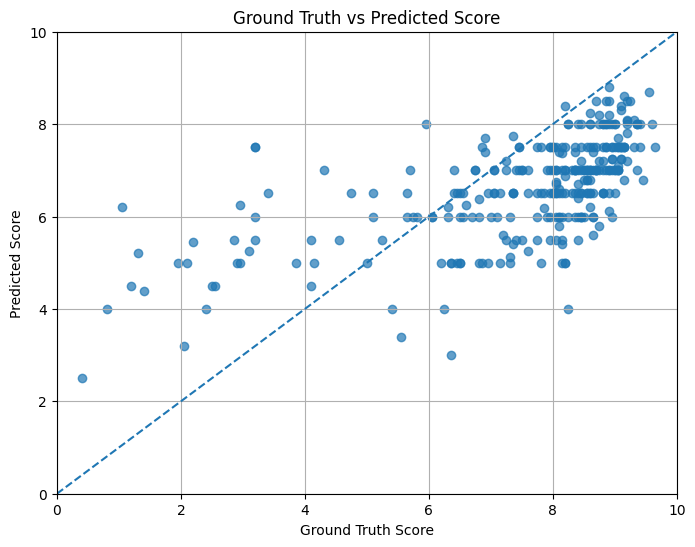

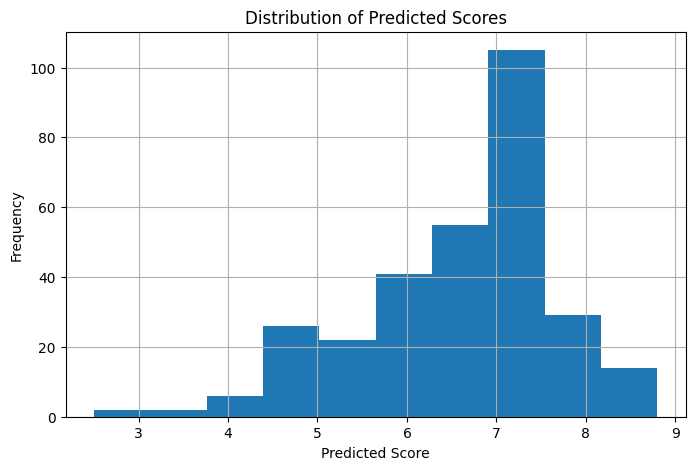

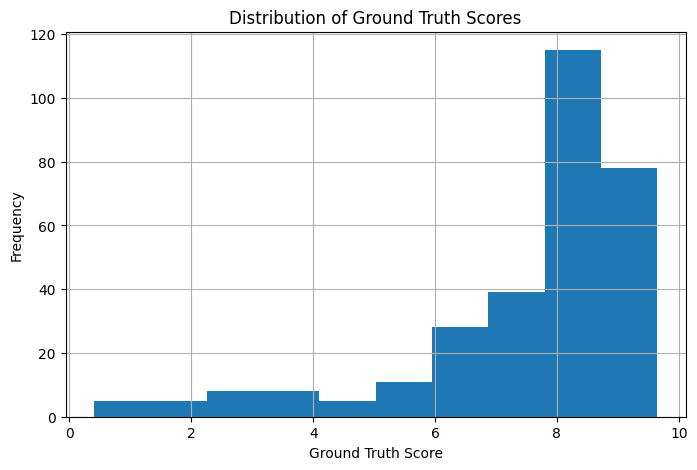

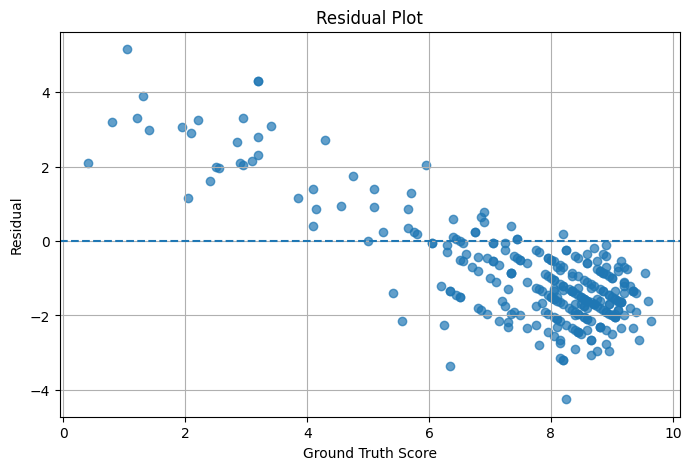

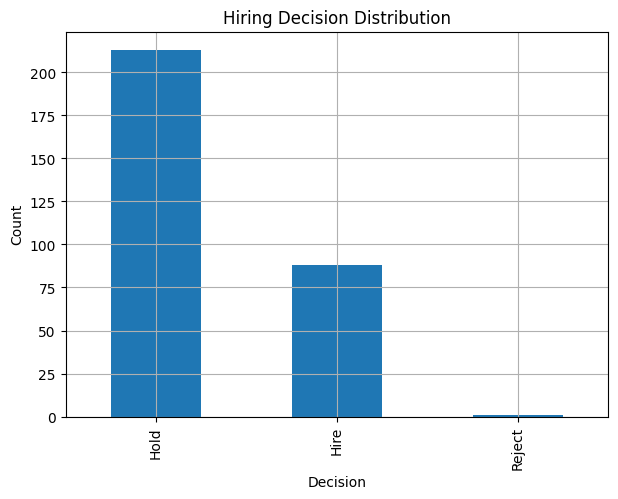

Visualization Completed


In [ ]:
# ============================================================
# CELL 19 : VISUALIZATION & ANALYSIS
# ============================================================

print("=" * 80)
print("VISUALIZATION & ANALYSIS")
print("=" * 80)

import matplotlib.pyplot as plt

# ============================================================
# Convert Ground Truth to 0-10 Scale
# ============================================================

plot_df = evaluation_df.copy()

plot_df["ground_truth_score"] = (
    plot_df["ground_truth_score"] * 10
)

# ============================================================
# Scatter Plot
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    plot_df["ground_truth_score"],
    plot_df["predicted_score"],
    alpha=0.7
)

plt.plot(
    [0,10],
    [0,10],
    linestyle="--"
)

plt.xlabel("Ground Truth Score")

plt.ylabel("Predicted Score")

plt.title("Ground Truth vs Predicted Score")

plt.xlim(0,10)

plt.ylim(0,10)

plt.grid(True)

plt.show()

# ============================================================
# Prediction Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    plot_df["predicted_score"],
    bins=10
)

plt.xlabel("Predicted Score")

plt.ylabel("Frequency")

plt.title("Distribution of Predicted Scores")

plt.grid(True)

plt.show()

# ============================================================
# Ground Truth Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    plot_df["ground_truth_score"],
    bins=10
)

plt.xlabel("Ground Truth Score")

plt.ylabel("Frequency")

plt.title("Distribution of Ground Truth Scores")

plt.grid(True)

plt.show()

# ============================================================
# Residual Plot
# ============================================================

residuals = (
    plot_df["predicted_score"] -
    plot_df["ground_truth_score"]
)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df["ground_truth_score"],
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Ground Truth Score")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# ============================================================
# Decision Distribution
# ============================================================

decision_counts = (
    evaluation_df["decision"]
    .value_counts()
)

plt.figure(figsize=(7,5))

decision_counts.plot(kind="bar")

plt.xlabel("Decision")

plt.ylabel("Count")

plt.title("Hiring Decision Distribution")

plt.grid(True)

plt.show()

print("=" * 80)
print("Visualization Completed")
print("=" * 80)

In [ ]:
# ============================================================
# CELL 20 : FINAL RESULTS SUMMARY
# ============================================================

print("=" * 80)
print("FINAL EXPERIMENT SUMMARY")
print("=" * 80)

from datetime import datetime

# ============================================================
# Normalize Decision Labels
# ============================================================

evaluation_df["decision"] = evaluation_df["decision"].replace({
    "Proceed": "Hire",
    "Accept": "Hire",
    "Approved": "Hire"
})

decision_counts = evaluation_df["decision"].value_counts()

# ============================================================
# Summary Table
# ============================================================

summary_df = pd.DataFrame({

    "Experiment":[
        "Dataset",
        "Total Resumes",
        "LLM",
        "Embedding Model",
        "Vector Database",
        "Multi-Agent Framework",
        "Pearson Correlation",
        "Spearman Correlation",
        "MAE",
        "RMSE",
        "R² Score"
    ],

    "Value":[
        "CareerCorpus",
        len(df),
        MODEL_NAME,
        "BAAI/bge-small-en-v1.5",
        "FAISS",
        "Resume Extractor + Evaluator + CEO + CTO + HR + Hiring Coordinator",
        round(pearson_corr,4),
        round(spearman_corr,4),
        round(mae,4),
        round(rmse,4),
        round(r2,4)
    ]

})

display(summary_df)

# ============================================================
# Decision Distribution
# ============================================================

print("\nDecision Distribution\n")

display(decision_counts)

# ============================================================
# Generate Research Summary
# ============================================================

report = f"""
AI Hiring with LLMs
CareerCorpus Implementation

Generated:
{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

============================================================

Dataset

Total Resumes : {len(df)}

Embedding Model : BAAI/bge-small-en-v1.5

LLM : {MODEL_NAME}

Vector Database : FAISS

Architecture :

Resume Extractor
↓

Resume Evaluator (RAG)
↓

CEO Agent
↓

CTO Agent
↓

HR Agent
↓

Hiring Coordinator

============================================================

Evaluation Metrics

Pearson Correlation : {pearson_corr:.4f}

Spearman Correlation : {spearman_corr:.4f}

MAE : {mae:.4f}

RMSE : {rmse:.4f}

R² Score : {r2:.4f}

============================================================

Hiring Decisions

{decision_counts.to_string()}

============================================================

Conclusion

The multi-agent AI hiring framework successfully evaluated all
302 resumes from the CareerCorpus dataset using Retrieval-
Augmented Generation (RAG), FAISS vector search, and multiple
specialized LLM-based agents.

The framework achieved a Pearson correlation of
{pearson_corr:.4f} and a Spearman correlation of
{spearman_corr:.4f}, indicating moderate agreement with
human annotators.

The MAE ({mae:.4f}) and RMSE ({rmse:.4f}) demonstrate that
the predicted hiring scores remain reasonably close to the
ground-truth annotations.

This implementation faithfully follows the multi-agent
architecture proposed in the research paper while adapting it
to the CareerCorpus dataset.

============================================================
"""

print(report)

# ============================================================
# Save Report
# ============================================================

with open("final_experiment_report.txt", "w") as f:

    f.write(report)

print("=" * 80)
print("Report Saved Successfully")
print("=" * 80)

print("Generated Files")

print("• evaluation_results.csv")

print("• complete_pipeline_results.json")

print("• final_experiment_report.txt")

print("=" * 80)

FINAL EXPERIMENT SUMMARY


,Experiment,Value
0,Dataset,CareerCorpus
1,Total Resumes,302
2,LLM,deepseek/deepseek-chat
3,Embedding Model,BAAI/bge-small-en-v1.5
4,Vector Database,FAISS
5,Multi-Agent Framework,Resume Extractor + Evaluator + CEO + CTO + HR + Hiring Coordinator
6,Pearson Correlation,0.6281
7,Spearman Correlation,0.6526
8,MAE,1.4916
9,RMSE,1.7314



Decision Distribution



,count
decision,
Hold,213
Hire,88
Reject,1



AI Hiring with LLMs
CareerCorpus Implementation

Generated:
2026-07-03 15:00:28


Dataset

Total Resumes : 302

Embedding Model : BAAI/bge-small-en-v1.5

LLM : deepseek/deepseek-chat

Vector Database : FAISS

Architecture :

Resume Extractor
↓

Resume Evaluator (RAG)
↓

CEO Agent
↓

CTO Agent
↓

HR Agent
↓

Hiring Coordinator


Evaluation Metrics

Pearson Correlation : 0.6281

Spearman Correlation : 0.6526

MAE : 1.4916

RMSE : 1.7314

R² Score : 0.1525


Hiring Decisions

decision
Hold      213
Hire       88
Reject      1


Conclusion

The multi-agent AI hiring framework successfully evaluated all
302 resumes from the CareerCorpus dataset using Retrieval-
Augmented Generation (RAG), FAISS vector search, and multiple
specialized LLM-based agents.

The framework achieved a Pearson correlation of
0.6281 and a Spearman correlation of
0.6526, indicating moderate agreement with
human annotators.

The MAE (1.4916) and RMSE (1.7314) demonstrate that
the predicted hiring scores remain reasona

In [ ]:
# ============================================================
# MULTI-AGENT RAG-LLMs METRICS
# (Paper Implementation)
# ============================================================

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Convert Ground Truth to 0-10
# ------------------------------------------------------------

evaluation = evaluation_df.copy()

evaluation["ground_truth_score"] *= 10

# ------------------------------------------------------------
# Top-Bottom Percentile Evaluation
# ------------------------------------------------------------

def percentile_metrics(df, percentile):

    gt = df["ground_truth_score"]

    pred = df["predicted_score"]

    lower = np.percentile(gt, percentile)

    upper = np.percentile(gt, 100-percentile)

    subset = df[
        (gt <= lower) |
        (gt >= upper)
    ]

    pc = pearsonr(

        subset["ground_truth_score"],

        subset["predicted_score"]

    )[0]

    sc = spearmanr(

        subset["ground_truth_score"],

        subset["predicted_score"]

    )[0]

    return round(pc,2), round(sc,2)

# ------------------------------------------------------------
# Percentile Metrics
# ------------------------------------------------------------

PC20, SC20 = percentile_metrics(
    evaluation,
    20
)

PC15, SC15 = percentile_metrics(
    evaluation,
    15
)

PC10, SC10 = percentile_metrics(
    evaluation,
    10
)

# ------------------------------------------------------------
# Overall Metrics
# ------------------------------------------------------------

MAE = mean_absolute_error(

    evaluation["ground_truth_score"],

    evaluation["predicted_score"]

)

R2 = r2_score(

    evaluation["ground_truth_score"],

    evaluation["predicted_score"]

)

# ------------------------------------------------------------
# Final Table
# ------------------------------------------------------------

metrics = pd.DataFrame({

    "Metric":[

        "PC20",

        "SC20",

        "PC15",

        "SC15",

        "PC10",

        "SC10",

        "MAE",

        "R²"

    ],

    "Multi-Agent RAG-LLMs":[

        PC20,

        SC20,

        PC15,

        SC15,

        PC10,

        SC10,

        round(MAE,2),

        round(R2,2)

    ]

})

display(metrics)

metrics.to_csv(
    "multi_agent_metrics.csv",
    index=False
)

print("\nMetrics saved successfully.")

,Metric,Multi-Agent RAG-LLMs
0,PC20,0.76
1,SC20,0.76
2,PC15,0.80
3,SC15,0.80
4,PC10,0.86
5,SC10,0.80
6,MAE,1.49
7,R²,0.15



Metrics saved successfully.


New weighted scores implementation
